In [1]:
%pip install matplotlib numpy tensorflow scipy pandas scikit-learn

  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   --------- ------------------------------ 2.1/8.9 MB 10.7 MB/s eta 0:00:01
   --------------- ------------------------ 3.4/8.9 MB 9.6 MB/s eta 0:00:01
   --------------- ------------------------ 3.4/8.9 MB 9.6 MB/s eta 0:00:01
   ----------------- ---------------------- 3.9/8.9 MB 4.6 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/8.9 MB 4.8 MB/s eta 0:00:01
   ---------------------------- ----------- 6.3/8.9 MB 5.0 MB/s eta 0:00:01
   ---------------------------------- ----- 7.6/8.9 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 5.4 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ---------

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Paths
TRAIN_DIR = "../data/training"
VAL_DIR = "../data/testing"
MODEL_OUT = "../models/xception_dr.h5"

# Params
IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-4
NUM_CLASSES = 5


In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Classes:", train_gen.class_indices)


Found 3662 images belonging to 5 classes.
Found 734 images belonging to 5 classes.
Classes: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [4]:
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.summary()




Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 149, 149, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 149, 149, 32)         0         ['block1_conv1_bn[0][0]'

In [5]:
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [6]:
callbacks = [
    ModelCheckpoint(
        MODEL_OUT,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        verbose=1
    )
]


In [8]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
115/115 [==============================] - ETA: 0s - loss: 0.8418 - accuracy: 0.7015
Epoch 1: val_loss improved from inf to 0.91277, saving model to ../models\xception_dr.h5


d:\fundus-dr-app\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


115/115 [==============================] - 347s 3s/step - loss: 0.8418 - accuracy: 0.7015 - val_loss: 0.9128 - val_accuracy: 0.6281 - lr: 1.0000e-04
Epoch 2/30
115/115 [==============================] - ETA: 0s - loss: 0.7648 - accuracy: 0.7215
Epoch 2: val_loss improved from 0.91277 to 0.85105, saving model to ../models\xception_dr.h5
115/115 [==============================] - 348s 3s/step - loss: 0.7648 - accuracy: 0.7215 - val_loss: 0.8510 - val_accuracy: 0.6458 - lr: 1.0000e-04
Epoch 3/30
115/115 [==============================] - ETA: 0s - loss: 0.7158 - accuracy: 0.7406
Epoch 3: val_loss improved from 0.85105 to 0.83509, saving model to ../models\xception_dr.h5
115/115 [==============================] - 351s 3s/step - loss: 0.7158 - accuracy: 0.7406 - val_loss: 0.8351 - val_accuracy: 0.6594 - lr: 1.0000e-04
Epoch 4/30
115/115 [==============================] - ETA: 0s - loss: 0.6924 - accuracy: 0.7463
Epoch 4: val_loss improved from 0.83509 to 0.72925, saving model to ../models\x

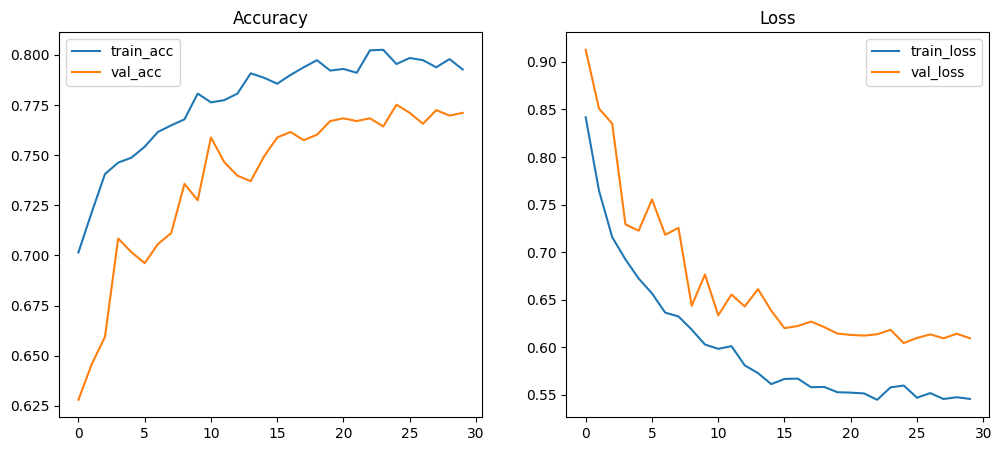

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.show()


In [10]:
model.save(MODEL_OUT)
print("Model saved to:", MODEL_OUT)


Model saved to: ../models/xception_dr.h5
